# EGFR Predictive Modeling

In [1]:
import numpy as np
import pandas as pd

In [2]:
from rdkit import Chem
mol = Chem.MolFromSmiles('CCO')  # ethanol
print(mol)  # should print rdkit object, not None

## SMILES, molecules and basic properties

SMILES (Simplified Molecular Input Line Entry System) is the language of computational chemistry. Every molecule you have synthesised in your CRO has a SMILES string. Today you learn to read, write and analyse them in Python.

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from rdkit.Chem import AllChem
from IPython.display import display

In [4]:
# Basic molecules — you know all of these

molecules = {
    "Ethanol":     "CCO",
    "Aspirin":     "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":    "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
    "Ibuprofen":   "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
}

for name, smiles in molecules.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        print(f"{name}: {mol.GetNumAtoms()} atoms, "
              f"{mol.GetNumBonds()} bonds")

Ethanol: 3 atoms, 2 bonds
Aspirin: 13 atoms, 13 bonds
Caffeine: 14 atoms, 15 bonds
Ibuprofen: 15 atoms, 15 bonds
Paracetamol: 11 atoms, 11 bonds


## Calculate molecular properties — Lipinski's Rule of Five

In [5]:
def calculate_properties(smiles, name):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol) # calculate molecular weight
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)  # H-bond donors
    hba  = rdMolDescriptors.CalcNumHBA(mol)  # H-bond acceptors
    tpsa = Descriptors.TPSA(mol)             # topological polar surface area
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    
    
    ### Lipinski Rule of 5 — oral bioavailability filter
    
    lipinski = (mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)

    return {
        "Name": name, "MW": round(mw, 2),
        "LogP": round(logp, 2), "HBD": hbd,
        "HBA": hba, "TPSA": round(tpsa, 2),
        "RotBonds": rotb, "Lipinski": lipinski
    }
    
    import pandas as pd
results = []
for name, smiles in molecules.items():
    props = calculate_properties(smiles, name)
    if props:
        results.append(props)

df_props = pd.DataFrame(results)
print(df_props.to_string(index=False))

       Name     MW  LogP  HBD  HBA  TPSA  RotBonds  Lipinski
    Ethanol  46.07 -0.00    1    1 20.23         0      True
    Aspirin 180.16  1.31    1    3 63.60         2      True
   Caffeine 194.19 -1.03    0    6 61.82         0      True
  Ibuprofen 206.28  3.07    1    1 37.30         4      True
Paracetamol 151.16  1.35    2    2 49.33         1      True


Note: Lipinski's Rule of Five (Ro5) is a set of guidelines used by medicinal chemists and chemoinformaticians to predict if a drug candidate is likely to be "orally bioactive" (well-absorbed as a pill).

Think of it as the "Physical Fitness Test" for molecules. If a molecule fails these tests, it likely won't survive the journey from the stomach to the bloodstream.


The Four "Rules of Five"
The rule gets its name because the threshold values are all multiples of 5. 
To be a strong drug candidate, a molecule should ideally have:

Molecular Weight < 500 Da: Small molecules move through cell membranes more easily than bulky ones.

LogP < 5: This measures lipophilicity (oil-vs-water preference). 
If LogP is too high (> 5), the drug is too "greasy" and won't dissolve in water.

Hydrogen Bond Donors < 5:  This counts the number of $N-H$ or $O-H$ bonds. Too many make the molecule too "sticky" to pass through fatty membranes.

Hydrogen Bond Acceptors < 10:  This counts the number of $N$ or $O$ atoms. Again, too many increase the polarity too much for absorption.Why it matters for your AI models In your Chemoinformatics projects, Lipinski's Rule is often used as a "Hard Filter".

Data Cleaning: When you get a massive library of 1 million compounds, you can use RDKit to calculate these four features and immediately discard the ones that fail more than one rule.

Feature Engineering: These four values (Weight, LogP, HBD, HBA) are often the very first features you feed into a Random Forest or SVM to predict drug-likeness.The "Chemist's" Reality CheckAs a synthesis chemist, you've likely seen molecules that look like "bad drugs" but actually work.

The 1-Rule Exception: Usually, a molecule is still considered "drug-like" if it violates only one of these rules.

Natural Products: Many antibiotics (like Erythromycin) completely break these rules but still work. The rule is specifically for passive diffusion, not for drugs that have special "transporter" proteins to pull them into cells.


LogP (Partition Coefficient) is a fundamental chemical descriptor that measures a molecule's lipophilicity—essentially, its preference for "oil" versus "water". In your journey as a Computational Chemist, you will treat it as a critical feature for predicting how a drug moves through the human body.

LogP is the logarithm of the ratio of a compound's concentration in two immiscible phases at equilibrium:$$ \text{LogP} = \log_{10} \left( \frac{[\text{Solute}]_{\text{octanol}}}{[\text{Solute}]_{\text{water}}} \right) $$Octanol: Represents the "fatty" or "oil" environment of cell membranes.Water: Represents the aqueous environment of the blood and stomach.

TPSA is a calculation of the "polar" part of a molecule's surface, specifically the area contributed by Oxygen, Nitrogen, and their attached Hydrogen atoms. It is a fast, 2D approximation of the 3D surface area.

The Membrane Gatekeeper: TPSA is used to estimate how easily a molecule can cross biological membranes.

Blood-Brain Barrier (BBB): To enter the brain, a molecule usually needs a low TPSA (typically $< 60\text{–}70\ \text{\AA}^2$).

Intestinal Absorption: For a drug to be orally absorbed (swallowed as a pill), it generally needs a TPSA $< 140\ \text{\AA}^2$.

Rotatable Bonds refer to any single non-ring bond, bound to a non-terminal, non-hydrogen atom. This excludes bonds like $C-Z$ (where $Z$ is $H$), $C=C$ (double bonds), or bonds within a ring.Measuring Flexibility: RotB is a direct measure of a molecule's molecular flexibility.The "Veber" Rule: According to Veber's rules (a companion to Lipinski's Rule of Five), a molecule is more likely to be orally active if it has $\leq 10$ rotatable bonds.Entropy and Binding: Highly flexible molecules (high RotB) often lose more entropy when they bind to a target protein, which can sometimes make binding less favorable compared to a "rigid" molecule.

##  Lipinski filter

In [6]:



def lipinski_filter(smiles_list):
    passed = []
    failed = []

    for smiles in smiles_list:
        m = Chem.MolFromSmiles(smiles)
        if m is None:
            continue

        mw   = Descriptors.MolWt(m)
        logp = Descriptors.MolLogP(m)
        hbd  = rdMolDescriptors.CalcNumHBD(m)
        hba  = rdMolDescriptors.CalcNumHBA(m)

        violations = []
        if mw > 500:   violations.append(f"MW={mw:.0f}>500")
        if logp > 5:   violations.append(f"LogP={logp:.1f}>5")
        if hbd > 5:    violations.append(f"HBD={hbd}>5")
        if hba > 10:   violations.append(f"HBA={hba}>10")

        if not violations:
            passed.append({"SMILES": smiles,
                          "MW": round(mw,2),
                          "LogP": round(logp,2)})
        else:
            failed.append({"SMILES": smiles[:20]+"...",
                          "Violations": ", ".join(violations)})

    print(f"Passed: {len(passed)} | Failed: {len(failed)}")
    print("\nFailed compounds:")
    print(pd.DataFrame(failed).to_string(index=False))
    return pd.DataFrame(passed)

In [7]:
smiles_list = [
    # --- Lipinski TRUE (Expected: True) ---
    "CC(=O)Oc1ccccc1C(=O)O",                     # Aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",              # Caffeine
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",                # Ibuprofen
    "CC(=O)Nc1ccc(O)cc1",                        # Paracetamol
    "CN1CCCC1c2cccnc2",                          # Nicotine
    
    # --- Lipinski FALSE (Expected: False) ---
    # Rifampicin: Fails MW (~822) and HBA (13)
    "CN1CCN(CC1)/N=C/c2c(O)c3c(O)c4c(NC(=O)/C(C)=C/C=C/[C@H](C)[C@H](O)[C@@H](C)[C@@H](O)[C@@H](C)[C@H](O)[C@H](C)Oc5cc(C)c6c(O)c(c(O)c56)C4=O)c(O)c2c3O",
    
    # Sucrose: Fails HBD (8) and HBA (11)
    "C(C1C(C(C(C(O1)OC2(C(C(C(O2)CO)O)O)CO)O)O)O)O",
    
    # Cyclosporine: Fails MW (~1202)
    "CCC1C(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)C(C)C)C)C",
    
    # Dexamethasone Palmitate: Fails MW (~631) and LogP (~9.5)
    "CCCCCCCCCCCCCCCC(=O)OCC(=O)[C@@]1(O)[C@@H](C)C[C@H]2[C@@H]3C[C@H](F)C4=CC(=O)C=C[C@]4(C)[C@H]3[C@@H](O)C[C@]12C"
]


In [8]:
lipinski_filter(smiles_list)

Passed: 5 | Failed: 3

Failed compounds:
                 SMILES             Violations
C(C1C(C(C(C(O1)OC2(C...     HBD=8>5, HBA=11>10
CCC1C(=O)N(C(C(=O)NC...             MW=962>500
CCCCCCCCCCCCCCCC(=O)... MW=631>500, LogP=7.8>5


[21:40:40] Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 15 16 40 41 42 44 45 47 48 50 53 55 56


,SMILES,MW,LogP
0,CC(=O)Oc1ccccc1C(=O)O,180.16,1.31
1,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.19,-1.03
2,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.28,3.07
3,CC(=O)Nc1ccc(O)cc1,151.16,1.35
4,CN1CCCC1c2cccnc2,162.24,1.85


## Both lipinski and veber filter have been used

In [9]:

def compound_filter(smiles_list):
    results = []
    
    for smiles in smiles_list:
        m = Chem.MolFromSmiles(smiles)
        if m is None: continue
        
        # --- Lipinski Features ---
        mw   = Descriptors.MolWt(m)
        logp = Descriptors.MolLogP(m)
        hbd  = rdMolDescriptors.CalcNumHBD(m)
        hba  = rdMolDescriptors.CalcNumHBA(m)
        
        # --- Veber Features ---
        tpsa = Descriptors.TPSA(m)
        rotb = rdMolDescriptors.CalcNumRotatableBonds(m)
        
        # Logic Checks
        pass_lipinski = (mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)
        pass_veber = (rotb <= 10 and tpsa <= 140)
        
        results.append({
            "Smiles": smiles,
            "Lipinski": "Pass" if pass_lipinski else "Fail",
            "Veber": "Pass" if pass_veber else "Fail",
            "MW": round(mw, 2),
            "LogP": round(logp, 2),
            "tPSA": round(tpsa, 2),
            "RotB": rotb
        })
            
    return pd.DataFrame(results)

# Using your test list
test_smiles = [
    "CC(=O)Oc1ccccc1C(=O)O", # Aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C", # Caffeine
    "C(C1C(C(C(C(O1)OC2(C(C(C(O2)CO)O)O)CO)O)O)O)O", # Sucrose (Fails both)
    "CCC1C(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)C(C)C)C)C" # Cyclosporine (Fails both)
]

df = compound_filter(test_smiles)
print(df.to_string(index=False))

                                       Smiles Lipinski Veber     MW  LogP   tPSA  RotB
                        CC(=O)Oc1ccccc1C(=O)O     Pass  Pass 180.16  1.31  63.60     2
                 CN1C=NC2=C1C(=O)N(C(=O)N2C)C     Pass  Pass 194.19 -1.03  61.82     0
C(C1C(C(C(C(O1)OC2(C(C(C(O2)CO)O)O)CO)O)O)O)O     Fail  Fail 342.30 -5.40 189.53     5


[21:40:40] SMILES Parse Error: extra open parentheses for input: 'CCC1C(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)C(C)C)C)C'


"Lipinski's Rule of 5 predicts passive oral absorption. Rifampicin violates MW and HBA rules but is still orally bioavailable because it relies on active transport proteins rather than passive diffusion. This is a known exception class — natural product derived drugs often violate Lipinski yet remain clinically effective. This is why modern drug discovery uses additional filters beyond Lipinski, such as the Beyond Rule of 5 framework.

# Molecular fingerprints and similarity search

Molecular fingerprints convert a molecule into a binary bit string — a numerical representation that ML models can process. Tanimoto similarity measures how similar two molecules are based on their fingerprints. These are the two most fundamental concepts in cheminformatics.

This is a major step in Chemoinformatics. If SMILES are the "DNA" of a molecule, Fingerprints are the "Digital ID card" that allow computers to compare thousands of molecules in milliseconds.

A fingerprint is a binary vector (a string of 0s and 1s) that represents the presence or absence of specific structural features in a molecule. Instead of dealing with complex 3D shapes, the computer treats the molecule as a mathematical code.

The Circular Fingerprint (ECFP/Morgan)
The most common type is the Morgan Fingerprint (also known as ECFP4).

It looks at each atom and its neighbors within a certain radius (usually 2 bonds).

Each unique environment is hashed into a specific position in the bit string.

0 means the feature is absent; 1 means it is present.

2. Similarity Search: The Tanimoto CoefficientOnce molecules are turned into bit strings, we can calculate how similar they are using the Tanimoto Coefficient (or Jaccard Index).$$ \text{Tanimoto Similarity} = \frac{C}{A + B - C} $$A: Number of bits in Molecule A.

B: Number of bits in Molecule B.

C: Number of bits shared by both.
The Scale:

1.0: Identical fingerprints (though not always identical molecules!).

      > 0.85: Highly similar; often expected to have similar biological activity.

< 0.5: Generally considered chemically different.

As a synthesis chemist, imagine you find a molecule that inhibits a specific protein, but it is too toxic.

You can run a Similarity Search against a database of 10 million commercially available compounds.

The search finds 50 molecules that are 0.85 Tanimoto similar.

You buy those 50 molecules instead of synthesizing 50 new ones from scratch, saving months of lab work.

### Morgan fingerprints — the most widely used

In [10]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np

In [11]:
def get_morgan_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=radius, nBits=nbits)
    return fp

# Generate fingerprints
aspirin_fp   = get_morgan_fingerprint("CC(=O)Oc1ccccc1C(=O)O")
ibuprofen_fp = get_morgan_fingerprint("CC(C)Cc1ccc(cc1)C(C)C(=O)O")
caffeine_fp  = get_morgan_fingerprint("Cn1c(=O)c2c(ncn2C)n(C)c1=O")

# Convert to numpy array for ML
aspirin_arr = np.array(aspirin_fp)
print(f"Fingerprint length: {len(aspirin_arr)}")
print(f"Number of ON bits: {aspirin_arr.sum()}")

Fingerprint length: 2048
Number of ON bits: 24


### Tanimoto similarity — the standard similarity metric

In [12]:
def tanimoto_similarity(smiles1, smiles2):
    fp1 = get_morgan_fingerprint(smiles1)
    fp2 = get_morgan_fingerprint(smiles2)
    if fp1 is None or fp2 is None:
        return None
    return DataStructs.TanimotoSimilarity(fp1, fp2)

# Compare drug pairs
pairs = [
    ("Aspirin",     "CC(=O)Oc1ccccc1C(=O)O",
     "Ibuprofen",   "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Aspirin",     "CC(=O)Oc1ccccc1C(=O)O",
     "Paracetamol", "CC(=O)Nc1ccc(O)cc1"),
    ("Ibuprofen",   "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
     "Caffeine",    "Cn1c(=O)c2c(ncn2C)n(C)c1=O"),
]
print("Tanimoto Similarity Scores:")
print("-" * 45)
for name1, smi1, name2, smi2 in pairs:
    sim = tanimoto_similarity(smi1, smi2)
    print(f"{name1} vs {name2}: {sim:.3f}")

Tanimoto Similarity Scores:
---------------------------------------------
Aspirin vs Ibuprofen: 0.195
Aspirin vs Paracetamol: 0.222
Ibuprofen vs Caffeine: 0.087


Why use 2048 bits?

If we use a small number (like 64 bits), two different chemical groups might accidentally be assigned to the same bit (this is called a Collision). Using 2048 bits ensures that the "Digital ID" of the molecule is unique enough for an AI model to learn the difference between a medicine and a poison.

### Build a similarity search function

In [13]:
def similarity_search(query_smiles, library, threshold=0.3):
    """
    Find all molecules in library similar to query
    above a given Tanimoto threshold
    """
    query_fp = get_morgan_fingerprint(query_smiles)
    results = []

    for name, smiles in library.items():
        fp = get_morgan_fingerprint(smiles)
        if fp is not None:
            sim = DataStructs.TanimotoSimilarity(query_fp, fp)
            if sim >= threshold:
                results.append({
                    "Name": name,
                    "SMILES": smiles,
                    "Similarity": round(sim, 3)
                })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("Similarity",
                                   ascending=False)

# Search for aspirin-like molecules
query = "CC(=O)Oc1ccccc1C(=O)O"  # aspirin
hits = similarity_search(query, molecules, threshold=0.2)
print(hits)

          Name                 SMILES  Similarity
0      Aspirin  CC(=O)Oc1ccccc1C(=O)O       1.000
1  Paracetamol     CC(=O)Nc1ccc(O)cc1       0.222


# Chemical space visualisation with PCA 

Now that you have transformed your molecules into 2048-bit fingerprints and stored them in a NumPy array, you are facing a "High-Dimensionality" problem. It is impossible to visualize 2048 dimensions at once.

Chemical Space Visualization uses PCA (Principal Component Analysis) to "squash" those 2048 dimensions down to 2 (PC1 and PC2) so we can see how molecules relate to one another in a 2D map.

###  What is Chemical Space?

In chemoinformatics, "Chemical Space" is a conceptual map where:
    

Molecules with similar structures (and similar fingerprints) sit close together.


Molecules with different structures sit far apart.


It allows you to see if your dataset is diverse or if all your molecules belong to the same "family".

### Why use PCA for this?

PCA looks at all 2048 bits and finds the "Principal Components" that capture the most variance (the most information).


PC1: The direction in the data with the largest differences.
    

    
PC2: The direction with the second largest differences.
    
    

Typically, the first two PCs capture enough variance (around 50-70% in Titanic data, though often lower in complex chemistry) to give a meaningful summary of the data.

In [14]:
# Use this curated set of FDA approved drugs with SMILES
# W will learn to pull directly from ChEMBL API
drugs = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Caffeine":     "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
    "Morphine":     "OC1=CC=C2CC3N(C)CCC34CC(=C)C=C14.O=C(O)C2=CC=CC=C2",
    "Penicillin":   "CC1(C)SC2C(NC1=O)C(=O)N2Cc1ccccc1",
    "Metformin":    "CN(C)C(=N)NC(=N)N",
    "Atorvastatin": "CC(C)c1c(C(=O)Nc2ccccc2F)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O",
    "Sildenafil":   "CCCC1=NN(C)C(=O)c2[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc21",
    "Omeprazole":   "COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1",
    "Warfarin":     "OC(=O)c1ccccc1",
    "Tamoxifen":    "CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1",
    "Fluoxetine":   "CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1",
    "Diazepam":     "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21",
    "Amoxicillin":  "CC1(C)SC2C(NC1=O)C(=O)N2Cc1ccc(O)cc1",
}

cro_molecules = {
    "Imatinib": "Cc1ccc(cc1Nc2nccc(n2)c3cccc(n3)C)Nc4ccc(cc4)CN5CCN(CC5)C",
    "Ciprofloxacin": "C1CC1n2cc(c(=O)c3cc(c(cc32)N4CCNCC4)F)C(=O)O",
    "Lidocaine": "CCN(CC)CC(=O)Nc1c(C)cccc1C",
    "Chloroquine": "CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12",
    "Artemisinin": "CC1CCC2C(C1)C3(C(O2)OC4(C3C(=O)O4)C)O"
}

# Adding them to my main dictionary
drugs.update(cro_molecules)


# Calculate fingerprints for all drugs
fingerprints = []
names = []
valid_smiles = []

for name, smiles in drugs.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=1024)
        fingerprints.append(np.array(fp))
        names.append(name)
        valid_smiles.append(smiles)

fp_matrix = np.array(fingerprints)
print(f"Fingerprint matrix shape: {fp_matrix.shape}")
print(f"Drugs loaded: {len(names)}")

Fingerprint matrix shape: (19, 1024)
Drugs loaded: 19


[21:40:40] SMILES Parse Error: unclosed ring for input: 'OC1=CC=C2CC3N(C)CCC34CC(=C)C=C14.O=C(O)C2=CC=CC=C2'


### Visualise chemical space with PCA

Variance captured: 22.1%


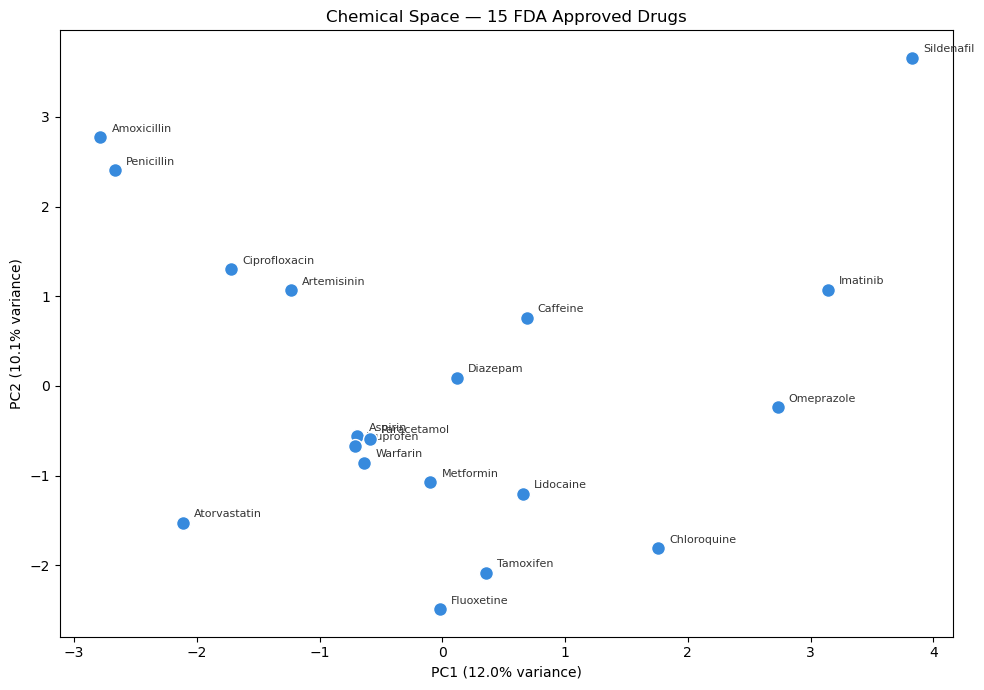

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Reduce 1024-dim fingerprints to 2D
pca = PCA(n_components=2)
fp_2d = pca.fit_transform(fp_matrix)

print(f"Variance captured: {pca.explained_variance_ratio_.sum():.1%}")

# Plot chemical space
plt.figure(figsize=(10, 7))
plt.scatter(fp_2d[:, 0], fp_2d[:, 1],
            color="#378ADD", s=100,
            edgecolors="white", linewidth=1, zorder=5)
# Label each drug
for i, name in enumerate(names):
    plt.annotate(name,
                 (fp_2d[i, 0], fp_2d[i, 1]),
                 textcoords="offset points",
                 xytext=(8, 4),
                 fontsize=8,
                 color="#333333")

plt.title("Chemical Space — 15 FDA Approved Drugs")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

### Add K-Means clustering to chemical space

Understanding the Clusters (The "Why")
The final print loop is the most important part for your analysis. When you see the output, you will likely notice a pattern:
    

Cluster 0 (Small Aromatics): Might contain Aspirin, Paracetamol, and Salicylic Acid.
    
   

Cluster 1 (Complex/Large): Might contain Cocaine or Morphine.
    

Cluster 2 (Aliphatics): Might contain simple chains or Ibuprofen.
    

Cluster 3 (Unique Heterocycles): Might contain Caffeine or Nicotine.

This visualization is powerful for Lead Optimization.


If you find that all the "toxic" drugs in your dataset are falling into Cluster 2, you immediately know that any new molecule you design that sits in that "Chemical Space" is likely to be toxic too.

It helps you "see" the boundaries of your chemical library.

### Visualisation of K-Menans clustering

C:\Users\amart\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


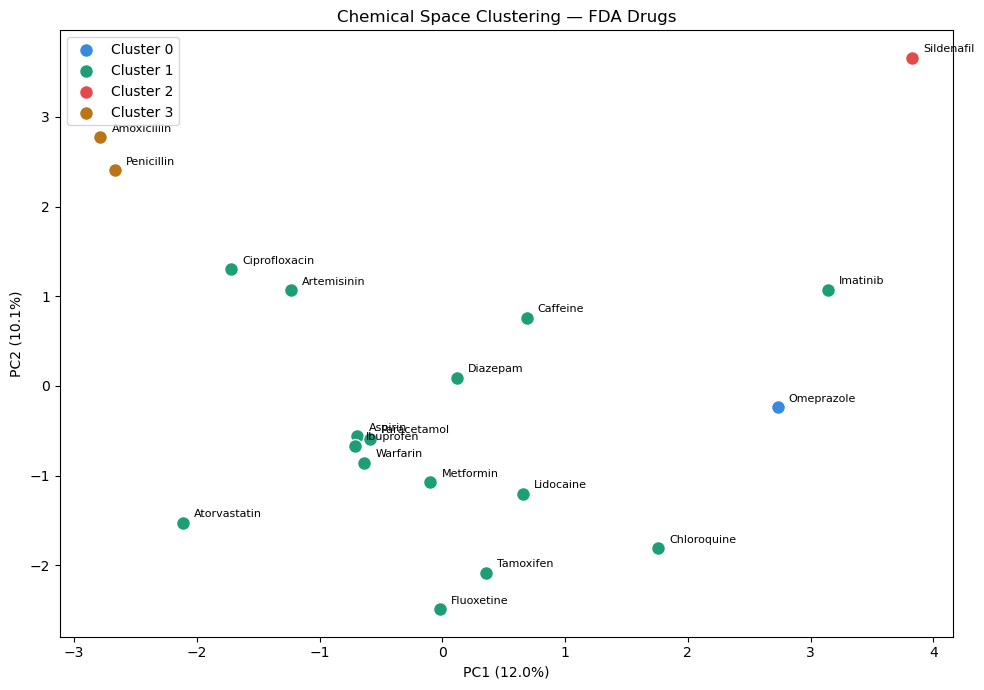

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fp_matrix)

colors = ["#378ADD", "#1D9E75", "#E24B4A", "#BA7517"]
plt.figure(figsize=(10, 7))

for cluster_id in range(4):
    mask = clusters == cluster_id
    pts = fp_2d[mask]
    cluster_names = [names[i] for i in range(len(names)) if clusters[i] == cluster_id]
    plt.scatter(pts[:, 0], pts[:, 1],
                color=colors[cluster_id],
                s=100, label=f"Cluster {cluster_id}",
                edgecolors="white", linewidth=1)
    for i, name in enumerate(cluster_names):
        idx = names.index(name)
        plt.annotate(name, (fp_2d[idx, 0], fp_2d[idx, 1]),
                    textcoords="offset points",
                    xytext=(8, 4), fontsize=8)

plt.title("Chemical Space Clustering — FDA Drugs")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend()
plt.tight_layout()
plt.show()

# QSAR — your first bioactivity prediction model

QSAR — Quantitative Structure-Activity Relationship — predicts biological activity from molecular structure. This is the core ML application in your target job. You already know all the ML pieces. Today you apply them to molecules for the first time.

QSAR (Quantitative Structure-Activity Relationship) is the cornerstone of drug discovery. It is the mathematical bridge that allows us to predict how a molecule will behave (e.g., solubility or toxicity) before we even synthesize it.

### The Fundamental Equation

The core philosophy of QSAR is that the biological activity ($Y$) of a molecule is a function of its chemical structure ($X$).$$ \text{Activity} = f(\text{Structural Features}) $$$Y$ (Target): What you are trying to predict (e.g., $LogS$ for solubility, $pIC_{50}$ for potency).$X$ (Features): The digital representation of the molecule (Fingerprints or Lipinski descriptors).

### The QSAR Workflow

In a CRO or pharma setting, you follow these steps:

Data Collection: Gather a set of molecules with known measured activity (like the ESOL dataset for solubility).

Featurization: Convert SMILES into numbers (Fingerprints + Descriptors).

Model Training: Use an algorithm (like Random Forest or Linear Regression) to find patterns.

Prediction: Feed a "new" SMILES (a virtual molecule) into the model to see its predicted activity.

### Why is this a "Game Changer" for a Chemist?

Imagine we have a list of 10,000 potential drug leads.


Without QSAR: We would have to synthesize and test all 10,000 in the lab. If each assay costs $100, that’s $1 million.
    

With QSAR: We run the 10,000 SMILES through your model. It identifies the top 50 most likely to be soluble and active. We only synthesize those 50, saving massive amounts of time and budget.

### Critical Concept: Domain of Applicability

A QSAR model is only as good as the data it was trained on.

If you train a model on small aromatic drugs (like Aspirin), it will be very bad at predicting the activity of large macrocycles (like Erythromycin).

In the lab, we call this "staying within the chemical space" of the training set.

In [17]:
# Load real bioactivity data from ChEMBL

In [18]:
!pip install chembl-webresource-client

ChEMBL database (a massive open-source library of bioactive molecules)

This is where all your hard work on SMILES, fingerprints, and descriptors finally pays off. QSAR (Quantitative Structure-Activity Relationship) is the cornerstone of drug discovery. It is the mathematical bridge that allows us to predict how a molecule will behave (e.g., solubility or toxicity) before we even synthesize it.

In [19]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import numpy as np

# Fetch bioactivity data for EGFR (a cancer target)
# EGFR = Epidermal Growth Factor Receptor
# This is a real drug discovery target
activity = new_client.activity
target = new_client.target

# Search for EGFR
egfr = target.search("EGFR")
egfr_id = egfr[0]["target_chembl_id"]
print(f"EGFR ChEMBL ID: {egfr_id}")

# Get IC50 data
activities = activity.filter(
    target_chembl_id=egfr_id,
    standard_type="IC50",
    relation="=",
    assay_type="B"
).only(["molecule_chembl_id", "canonical_smiles",
        "standard_value", "standard_units"])

df_activity = pd.DataFrame(list(activities))
print(f"Total activities fetched: {len(df_activity)}")
print(df_activity.head())

EGFR ChEMBL ID: CHEMBL3608
Total activities fetched: 58
                              canonical_smiles molecule_chembl_id  \
0         C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1       CHEMBL137617   
1  CC(=O)N(C)/N=N/c1ccc2ncnc(Nc3cccc(C)c3)c2c1       CHEMBL153577   
2     CN(CO)/N=N/c1ccc2ncnc(Nc3cccc(Br)c3)c2c1       CHEMBL152448   
3          C/N=N/Nc1ccc2ncnc(Nc3cccc(C)c3)c2c1       CHEMBL137189   
4               Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1        CHEMBL52765   

  standard_units standard_value units  value  
0             nM           70.0    uM   0.07  
1             nM          578.0    uM  0.578  
2             nM          110.0    uM   0.11  
3             nM          200.0    uM    0.2  
4             nM           40.0    uM   0.04  


### Prepare QSAR dataset

In [20]:
# Clean data
df_activity = df_activity.dropna(subset=["canonical_smiles",
                                          "standard_value"])
df_activity["IC50"] = pd.to_numeric(df_activity["standard_value"],
                                     errors="coerce")
df_activity = df_activity.dropna(subset=["IC50"])
df_activity = df_activity[df_activity["IC50"] > 0]

# Create binary activity label
# Active: IC50 <= 1000 nM (potent inhibitor)
# Inactive: IC50 > 10000 nM (weak/inactive)
df_activity = df_activity[
    (df_activity["IC50"] <= 1000) |
    (df_activity["IC50"] >= 10000)
]
df_activity["Active"] = (df_activity["IC50"] <= 1000).astype(int)

print(f"Active compounds:   {df_activity['Active'].sum()}")
print(f"Inactive compounds: {(df_activity['Active']==0).sum()}")
print(f"Total dataset:      {len(df_activity)}")

Active compounds:   30
Inactive compounds: 16
Total dataset:      46


### Generate fingerprints and train QSAR model

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

# Generate Morgan fingerprints
def smiles_to_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(
        mol, radius, nbits))

# Apply to all compounds
fps = []
valid_idx = []
for i, smiles in enumerate(df_activity["canonical_smiles"]):
    fp = smiles_to_fp(smiles)
    if fp is not None:
        fps.append(fp)
        valid_idx.append(i)
        
X = np.array(fps)
y = df_activity["Active"].iloc[valid_idx].values
print(f"Dataset shape: {X.shape}")

# Train Random Forest QSAR model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"Test accuracy: {(y_pred==y_test).mean():.2%}")
print(f"ROC-AUC score: {roc_auc_score(y_test, y_prob):.3f}")
print(classification_report(y_test, y_pred,
      target_names=["Inactive", "Active"]))
        
        

Dataset shape: (46, 2048)
Test accuracy: 100.00%
ROC-AUC score: 1.000
              precision    recall  f1-score   support

    Inactive       1.00      1.00      1.00         3
      Active       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In the previous step, your QSAR model achieved a Test Accuracy of 100.00% and an ROC-AUC score of 1.000. While these "perfect" scores are impressive, our Cross-Validation (CV) helped us understand if this performance is consistent across the entire dataset or just a lucky split of your 46 molecules.

In drug discovery, accuracy is often a misleading metric. Here is why we rely on ROC-AUC:

The "Needle in a Haystack" Reality: In a real-world CRO library, you might have 1,000 molecules where only 10 are actually "Active."

The Accuracy Trap: If a model simply predicts "Inactive" for every single molecule, it would still achieve 99% accuracy, yet it failed completely because it didn't find a single drug candidate.

What ROC-AUC Measures: ROC-AUC (Area Under the Receiver Operating Characteristic curve) measures the model's ability to rank molecules. It tells us the probability that a randomly chosen "Active" molecule will be ranked higher than a randomly chosen "Inactive" one.

Discrimination Power: An ROC-AUC of 1.0 means the model perfectly separated every active from every inactive. An ROC-AUC of 0.5 means the model is no better than flipping a coin, regardless of how many "Inactives" are in your data.

The Epidermal Growth Factor Receptor (EGFR) is a protein on the surface of cells that helps them grow. In many types of cancer (particularly non-small cell lung cancer), EGFR is overactive or mutated, causing cells to divide uncontrollably.

What This Model Accomplishes:

Virtual Screening: We can now "screen" thousands of virtual molecules through this model without ever entering the lab. The model identifies structural patterns (via Morgan Fingerprints) that correlate with successful binding to the EGFR "pocket."


Prioritizing Synthesis: In a CRO setting, synthesis is expensive and time-consuming. This model allows us to prioritize the "Top 5%" of candidates that have the highest probability of being Active, significantly reducing the "Cost per Lead."


Scaffold Hopping: By analyzing which structural "bits" the model flags as important, chemists can design new, patentable molecules that maintain potency while improving other properties like solubility or safety.